In [ ]:
class MSHA(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        assert embed_dim % num_head == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_head = num_head
        self.head_dim = embed_dim // num_head

        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, E = x.shape

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_head, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, N, E)
        out = self.out(out)

        return out, attn

# Pytorch Library

In [ ]:
from diffusers import StableDiffusionPipeline, DDIMScheduler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import numpy as np
from torch.utils.data import  Dataset, DataLoader
from torchvision.transforms.functional import to_pil_image, to_tensor
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from tqdm import tqdm
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Stable Diffusion(DDPM)

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

# Extract Feature

In [ ]:
q_out = None
k_out = None

def hook_q(module, input, output):
    global q_out
    q_out = output.detach()

def hook_k(module, input, output):
    global k_out
    k_out = output.detach()

for name, module in pipe.unet.named_modules():
    if "mid_block.attentions.0.transformer_blocks.0.attn1.to_q" in name:
        module.register_forward_hook(hook_q)
    if "mid_block.attentions.0.transformer_blocks.0.attn1.to_k" in name:
        module.register_forward_hook(hook_k)

def compute_attention_score(q, k, num_heads=8):
    B, N, D = q.shape
    dim_head = D // num_heads

    q = q.view(B, N, num_heads, dim_head).permute(0, 2, 1, 3)
    k = k.view(B, N, num_heads, dim_head).permute(0, 2, 1, 3)

    attn_scores = torch.matmul(q, k.transpose(-2, -1))
    attn_scores = attn_scores / (dim_head ** 0.5)

    attn_scores = F.softmax(attn_scores, dim=-1)
    return attn_scores

# DDPM Sampler

In [ ]:
def mu_tilde(model, xt,x0, timestep):
    "mu_tilde(x_t, x_0) DDPM paper eq. 7"
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    alpha_t = model.scheduler.alphas[timestep]
    beta_t = 1 - alpha_t
    alpha_bar = model.scheduler.alphas_cumprod[timestep]
    return ((alpha_prod_t_prev ** 0.5 * beta_t) / (1-alpha_bar)) * x0 +  ((alpha_t**0.5 *(1-alpha_prod_t_prev)) / (1- alpha_bar))*xt

def sample_xts_from_x0(model, x0, num_inference_steps=50):
    """
    Samples from P(x_1:T|x_0)
    """
    # torch.manual_seed(43256465436)
    alpha_bar = model.scheduler.alphas_cumprod
    sqrt_one_minus_alpha_bar = (1-alpha_bar) ** 0.5
    alphas = model.scheduler.alphas
    betas = 1 - alphas

    # 25.03.17 수정
    _, C, H, W = x0.size()

    timesteps = model.scheduler.timesteps.to(model.device)
    t_to_idx = {int(v):k for k,v in enumerate(timesteps)}
    xts = torch.zeros((num_inference_steps+1, C, H, W)).to(x0.device) # 25.03.17 수정
    xts[0] = x0
    for t in reversed(timesteps):
        idx = num_inference_steps-t_to_idx[int(t)]
        xts[idx] = x0 * (alpha_bar[t] ** 0.5) +  torch.randn_like(x0) * sqrt_one_minus_alpha_bar[t]


    return xts

def encode_text(model, prompts):

    text_input = model.tokenizer(
        prompts,
        padding="max_length",
        max_length=model.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    with torch.no_grad():
        text_encoding = model.text_encoder(text_input.input_ids.to(model.device))[0]
    return text_encoding

def forward_step(model, model_output, timestep, sample):
    next_timestep = min(model.scheduler.config.num_train_timesteps - 2,
                        timestep + model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps)

    # 2. compute alphas, betas
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    # alpha_prod_t_next = self.scheduler.alphas_cumprod[next_timestep] if next_ltimestep >= 0 else self.scheduler.final_alpha_cumprod

    beta_prod_t = 1 - alpha_prod_t

    # 3. compute predicted original sample from predicted noise also called
    # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)

    # 5. TODO: simple noising implementatiom
    next_sample = model.scheduler.add_noise(pred_original_sample,
                                    model_output,
                                    torch.LongTensor([next_timestep]))
    return next_sample


def get_variance(model, timestep): #, prev_timestep):
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    beta_prod_t = 1 - alpha_prod_t
    beta_prod_t_prev = 1 - alpha_prod_t_prev
    variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
    return variance

def inversion_forward_process(model, x0,
                            etas = None,
                            prog_bar = False,
                            prompt = "",
                            cfg_scale = 3.5,
                            num_inference_steps=50, eps = None):

    if not prompt=="":
        text_embeddings = encode_text(model, prompt)
    uncond_embedding = encode_text(model, "")
    timesteps = model.scheduler.timesteps.to(model.device)

    # 25.03.17 수정
    _, C, H, W = x0.size()

    if etas is None or (type(etas) in [int, float] and etas == 0):
        eta_is_zero = True
        zs = None
    else:
        eta_is_zero = False
        if type(etas) in [int, float]: etas = [etas]*model.scheduler.num_inference_steps
        xts = sample_xts_from_x0(model, x0, num_inference_steps=num_inference_steps)
        alpha_bar = model.scheduler.alphas_cumprod
        zs = torch.zeros((num_inference_steps, C, H, W)).to(x0.device) # 25.03.17 수정
    t_to_idx = {int(v):k for k,v in enumerate(timesteps)}
    xt = x0
    # op = tqdm(reversed(timesteps)) if prog_bar else reversed(timesteps)
    op = tqdm(timesteps) if prog_bar else timesteps

    #attention 저장 리스트
    attn_scores = []

    for t in op:
        # idx = t_to_idx[int(t)]
        idx = num_inference_steps-t_to_idx[int(t)]-1
        # 1. predict noise residual
        if not eta_is_zero:
            xt = xts[idx+1][None]
            # xt = xts_cycle[idx+1][None]

        with torch.no_grad():
            out = model.unet.forward(xt, timestep =  t, encoder_hidden_states = uncond_embedding)
            if not prompt=="":
                cond_out = model.unet.forward(xt, timestep=t, encoder_hidden_states = text_embeddings)

        if not prompt=="":
            ## classifier free guidance
            noise_pred = out.sample + cfg_scale * (cond_out.sample - out.sample)
        else:
            noise_pred = out.sample
        if eta_is_zero:
            # 2. compute more noisy image and set x_t -> x_t+1
            xt = forward_step(model, noise_pred, t, xt)

        else:
            # xtm1 =  xts[idx+1][None]
            xtm1 =  xts[idx][None]
            # pred of x0
            pred_original_sample = (xt - (1-alpha_bar[t])  ** 0.5 * noise_pred ) / alpha_bar[t] ** 0.5

            # direction to xt
            prev_timestep = t - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
            alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod

            variance = get_variance(model, t)
            pred_sample_direction = (1 - alpha_prod_t_prev - etas[idx] * variance ) ** (0.5) * noise_pred

            mu_xt = alpha_prod_t_prev ** (0.5) * pred_original_sample + pred_sample_direction

            z = (xtm1 - mu_xt ) / ( etas[idx] * variance ** 0.5 )
            zs[idx] = z

            # correction to avoid error accumulation
            #xtm1 = mu_xt + ( etas[idx] * variance ** 0.5 )*z
            #xts[idx] = xtm1

        # q_out, k_out으로 attention score 추출
        if q_out is not None and k_out is not None:
            attn_score = compute_attention_score(q_out, k_out, num_heads=8)
            attn_scores.append(attn_score)

    if not zs is None:
        zs[0] = torch.zeros_like(zs[0])

    return xt, zs, xts, attn_scores


def reverse_step(model, model_output, timestep, sample, eta = 0, variance_noise=None):
    # 1. get previous step value (=t-1)
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    # 2. compute alphas, betas
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    beta_prod_t = 1 - alpha_prod_t
    # 3. compute predicted original sample from predicted noise also called
    # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
    # 5. compute variance: "sigma_t(η)" -> see formula (16)
    # σ_t = sqrt((1 − α_t−1)/(1 − α_t)) * sqrt(1 − α_t/α_t−1)
    # variance = self.scheduler._get_variance(timestep, prev_timestep)
    variance = get_variance(model, timestep) #, prev_timestep)
    std_dev_t = eta * variance ** (0.5)
    # Take care of asymetric reverse process (asyrp)
    model_output_direction = model_output
    # 6. compute "direction pointing to x_t" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    # pred_sample_direction = (1 - alpha_prod_t_prev - std_dev_t**2) ** (0.5) * model_output_direction
    pred_sample_direction = (1 - alpha_prod_t_prev - eta * variance) ** (0.5) * model_output_direction
    # 7. compute x_t without "random noise" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    prev_sample = alpha_prod_t_prev ** (0.5) * pred_original_sample + pred_sample_direction

    # 8. Add noice if eta > 0
    if eta > 0:
        if variance_noise is None:
            variance_noise = torch.randn(model_output.shape, device=model.device)
        sigma_z =  eta * variance ** (0.5) * variance_noise
        prev_sample = prev_sample + sigma_z

    return prev_sample

def inversion_reverse_process(model,
                    xT,
                    etas = 0,
                    prompts = "",
                    cfg_scales = None,
                    prog_bar = False,
                    zs = None,
                    controller=None,
                    asyrp = False):

    # 수정(25.03.17)
    batch_size = max(1, len(prompts))

    text_embeddings = encode_text(model, prompts)

    # 수정(25.03.17)
    uncond_embedding = encode_text(model, "") if batch_size == 0 else encode_text(model, [""] * batch_size)

    if etas is None: etas = 0
    if type(etas) in [int, float]: etas = [etas]*model.scheduler.num_inference_steps
    assert len(etas) == model.scheduler.num_inference_steps
    timesteps = model.scheduler.timesteps.to(model.device)

    xt = xT.expand(batch_size, -1, -1, -1)
    op = tqdm(timesteps[-zs.shape[0]:]) if prog_bar else timesteps[-zs.shape[0]:]

    t_to_idx = {int(v):k for k,v in enumerate(timesteps[-zs.shape[0]:])}

    i = 0
    for t in op:

        idx = model.scheduler.num_inference_steps-t_to_idx[int(t)]-(model.scheduler.num_inference_steps-zs.shape[0]+1)
        ## Unconditional embedding

        with torch.no_grad():
            uncond_out = model.unet.forward(xt, timestep =  t,
                                            encoder_hidden_states = uncond_embedding)

            ## Conditional embedding
        if prompts:
            with torch.no_grad():
                cond_out = model.unet.forward(xt, timestep =  t,
                                                encoder_hidden_states = text_embeddings)

        z = zs[idx] if not zs is None else None
        z = z.expand(batch_size, -1, -1, -1)
        if prompts:
            ## classifier free guidance
            cfg_scales_tensor = torch.Tensor(cfg_scales).view(-1,1,1,1).to(model.device)
            noise_pred = uncond_out.sample + cfg_scales_tensor * (cond_out.sample - uncond_out.sample)
        else:
            noise_pred = uncond_out.sample

        xt = reverse_step(model, noise_pred, t, xt, eta = etas[idx], variance_noise = z)

        if controller is not None:
            xt = controller.step_callback(xt)

        i += 1

    return xt, zs

In [ ]:
# 25.03.17 작성
@torch.no_grad()
def DDPM_invert_sample(
    pipe,
    image,
    prompt = "",
    num_inference_steps=50,
    steps = 0,
    device=device,
):

    pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

    pipe.scheduler.set_timesteps(num_inference_steps)

    w0 = pipe.vae.encode(image * 2 - 1)
    w0 = 0.18215 * w0.latent_dist.sample()

    wt, zs, wts, attn_scores = inversion_forward_process(pipe, w0, etas=1, prompt = prompt, num_inference_steps=num_inference_steps)

    w0, _ = inversion_reverse_process(pipe, xT=wts[steps], etas=1, prog_bar=True, zs=zs[:steps])

    w0 = 1 / pipe.vae.config.scaling_factor * w0
    images = pipe.vae.decode(w0, return_dict=False)[0]
    images = (images / 2 + 0.5).clamp(0, 1)

    return images, attn_scores[0]

# Datasets

In [ ]:
class CropOrStitch:
    def __init__(self, target_size, train = False):

        self.target_size = target_size
        self.train = train

    def __call__(self, image):

        if isinstance(image, torch.Tensor):
            image = to_pil_image(image)

        width, height = image.size

        if width < self.target_size or height < self.target_size:
            repeat_h = (self.target_size // height) + 1
            repeat_w = (self.target_size // width) + 1

            stitched = torch.cat([torch.cat([to_tensor(image)] * repeat_w, dim=2)] * repeat_h, dim=1)

            image = to_pil_image(stitched[:, :self.target_size, :self.target_size])

        if self.train:
            crop_transform = transforms.RandomCrop(self.target_size)
        else:
            crop_transform = transforms.CenterCrop(self.target_size)

        return crop_transform(image)


train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    #transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((256,256)),
    #transforms.CenterCrop(224),
    transforms.ToTensor(),
])



In [ ]:
# train(sdv4)
sdv4_trainset = datasets.ImageFolder('/home/rmlab/datasets/genimage/sdv1.4/train',  transform = train_transform)

# test
adm = datasets.ImageFolder('/home/rmlab/datasets/genimage/adm/val', transform = test_transform)
biggan = datasets.ImageFolder('/home/rmlab/datasets/genimage/biggan/val', transform = test_transform)
glide = datasets.ImageFolder('/home/rmlab/datasets/genimage/glide/val', transform = test_transform)
midjourney = datasets.ImageFolder('/home/rmlab/datasets/genimage/midjourney/val', transform = test_transform)
sdv4 = datasets.ImageFolder('/home/rmlab/datasets/genimage/sdv1.4/val', transform = test_transform)
sdv5 = datasets.ImageFolder('/home/rmlab/datasets/genimage/sdv1.5/val', transform = test_transform)
vqdm = datasets.ImageFolder('/home/rmlab/datasets/genimage/vqdm/val', transform = test_transform)
wukong = datasets.ImageFolder('/home/rmlab/datasets/genimage/wukong/val', transform = test_transform)

trainloader = DataLoader(sdv4_trainset, batch_size = 32, shuffle = True)
admloader = DataLoader(adm, batch_size = 32, shuffle = False)
bigganloader = DataLoader(biggan, batch_size = 32, shuffle = False)
glideloader = DataLoader(glide, batch_size = 32, shuffle = False)
midjourneyloader = DataLoader(midjourney, batch_size = 32, shuffle = False)
sdv4loader = DataLoader(sdv4, batch_size = 32, shuffle = False)
sdv5loader = DataLoader(sdv5, batch_size = 32, shuffle = False)
vqdmloader = DataLoader(vqdm, batch_size = 32, shuffle = False)
wukongloader = DataLoader(wukong, batch_size = 32, shuffle = False)

print(len(sdv4_trainset))
print(len(adm))
print(len(biggan))
print(len(glide))
print(len(midjourney))
print(len(sdv4))
print(len(sdv5))
print(len(vqdm))
print(len(wukong))

In [ ]:
def pt_loader(path):
    return torch.load(path, weights_only=True)

trainset = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/train', loader=pt_loader, extensions=('.pt',))
adm = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/adm', loader=pt_loader, extensions=('.pt',))
biggan = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/biggan', loader=pt_loader, extensions=('.pt',))
glide = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/glide', loader=pt_loader, extensions=('.pt',))
midjourney = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/midjourney', loader=pt_loader, extensions=('.pt',))
sdv4 = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/sdv4', loader=pt_loader, extensions=('.pt',))
sdv5 = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/sdv5', loader=pt_loader, extensions=('.pt',))
vqdm = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/vqdm', loader=pt_loader, extensions=('.pt',))
wukong = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/wukong', loader=pt_loader, extensions=('.pt',))

In [ ]:
testset = datasets.ImageFolder('/content/drive/MyDrive/Colab Notebooks/종설2/data/image', transform = test_transform)
image, label = testset[0]
image = image.unsqueeze(0).to(device)
recon, attn_maps = DDPM_invert_sample(pipe, image, num_inference_steps=20,
                                                  steps=21, device=device)


IndexError: index 21 is out of bounds for dimension 0 with size 21

torch.Size([1, 8, 16, 16])
torch.Size([1, 3, 256, 256])


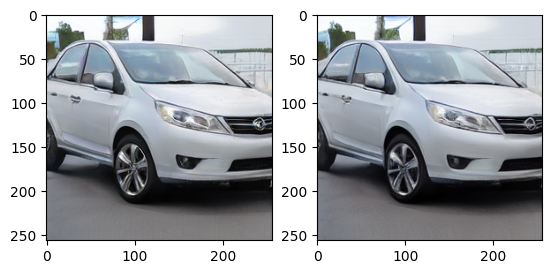

In [ ]:
print(attn_maps.shape)
print(recon.shape)

plt.subplot(1,2,1)
plt.imshow(to_pil_image(image.squeeze(0)))
plt.subplot(1,2,2)
plt.imshow(to_pil_image(recon.squeeze(0)))
plt.show()

# Classifier

In [ ]:
class MSHA(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        assert embed_dim % num_head == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_head = num_head
        self.head_dim = embed_dim // num_head

        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, E = x.shape

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_head, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, N, E)
        out = self.out(out)

        return out, attn

class MHSABlock(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.mhsa = MSHA(embed_dim, num_head)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.mhsa(x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

# 3. Temporal Aggregation Module
class TemporalAggregation(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.layers = nn.ModuleList([MHSABlock(embed_dim, num_head) for _ in range(4)])
        self.embed_dim = embed_dim
        self.proj = nn.Linear(8, embed_dim)
        self.proj_out = nn.Linear(embed_dim, 8)

    def forward(self, x):  # x: (B, T=20, D=8, H=16, W=16)
        B, T, D, H, W = x.shape
        out = torch.zeros((B, D, H, W)).to(x.device)
        #out = torch.zeros((B, self.embed_dim, H, W)).to(x.device)
        for i in range(H):
            for j in range(W):
                input = x[:, :, :, i, j] # (B, 20, 8)
                input = self.proj(input) # (B, 20, 128)
                for layer in self.layers:
                    input = layer(input) # (B, 20, 128)
                last_token = input[:, -1, :]  # (B, 128)
                last_token = self.proj_out(last_token) # (B, 8)
                out[:, :, i, j] = last_token # (B, 8, H, W)
        return out

# 4. Spatial Focusing Module
class SpatialFocusing(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8):
        super().__init__()
        self.avg_pool = lambda x: torch.mean(x, dim=1, keepdim=True)  # (B, 1, D, H, W)
        self.max_pool = lambda x: torch.max(x, dim=1, keepdim=True)[0]  # (B, 1, D, H, W)
        self.layers = nn.ModuleList([MHSABlock(embed_dim, num_heads) for _ in range(4)])
        self.conv = nn.Conv2d(2, 1, kernel_size=1)
        self.proj = nn.Linear(2*8, embed_dim)
        self.proj_out = nn.Linear(embed_dim, 2)

    def forward(self, x):  # x: (T, D, H, W)
        pooled = torch.cat([self.avg_pool(x), self.max_pool(x)], dim=1)  # (B, 2, 8, H, W)
        B, T, D, H, W = pooled.shape
        pooled = pooled.permute(0, 3, 4, 1, 2)            # (B, H, W, 2, D)
        pooled = pooled.reshape(B, H * W, 2 * D)          # (B, H*W, 2D)

        pooled = self.proj(pooled)                        # (B, H*W, embed_dim)
        for layer in self.layers:
            pooled = layer(pooled)                        # (B, H*W, embed_dim)

        pooled = self.proj_out(pooled)                    # (B, H*W, 2)
        pooled = pooled.permute(0, 2, 1)                  # (B, 2, H*W)
        pooled = pooled.reshape(B, 2, H, W)               # (B, 2, H, W)
        pooled = self.conv(pooled)                        # (B, 1, H, W)
        pooled = pooled.view(B, 1, -1)
        attention = F.softmax(pooled, dim=-1).view(B, 1, H, W) # (B, 1, H, W)

        return attention

# 5. Final Classifier
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(2048, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1),
        )

    def forward(self, x):  # x: (B, E, H, W)
        x = x.flatten(1)  # (B, E*H*W)
        x = self.fc(x)      # (B, 1)
        return torch.sigmoid(x)


# 6. Full TRE Detection Model
class TSC(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.temporal = TemporalAggregation(embed_dim, num_head)
        self.spatial = SpatialFocusing(embed_dim, num_head)
        self.classifier = Classifier()

    def forward(self, x):  # tre_feature: (B, T, D=8, H=16, W=16)
        Temporal = self.temporal(x)        # (B, E, 16, 16)
        Spatial = self.spatial(x)     # (B, 1, 16, 16)
        result = Temporal * Spatial
        return self.classifier(result)

In [ ]:
input = torch.randn(4, 20, 8, 16, 16)
print(input.shape)
#print(input)
model = TemporalAggregation()
output = model(input)
model = SpatialFocusing()
output = model(input)
model = TREClassifier()
output = model(input)
print(output.shape)
print(output)

torch.Size([4, 20, 8, 16, 16])
torch.Size([4, 1])
tensor([[0.5188],
        [0.5189],
        [0.5187],
        [0.5188]], grad_fn=<SigmoidBackward0>)


# spatial 대체


In [ ]:
class MHSA(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        assert embed_dim % num_head == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_head = num_head
        self.head_dim = embed_dim // num_head

        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, E = x.shape

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_head, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, N, E)
        out = self.out(out)

        return out, attn

class MHSABlock(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.mhsa = MHSA(embed_dim, num_head)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.mhsa(x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

# 3. Temporal Aggregation Module
class TemporalAggregation(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.layers = nn.ModuleList([MHSABlock(embed_dim, num_head) for _ in range(4)])
        self.embed_dim = embed_dim
        self.proj = nn.Linear(8, embed_dim)
        self.proj_out = nn.Linear(embed_dim, 8)

    def forward(self, x):  # x: (B, T=20, D=8, H=16, W=16)
        B, T, D, H, W = x.shape
        out = torch.zeros((B, D, H, W)).to(x.device)
        #out = torch.zeros((B, self.embed_dim, H, W)).to(x.device)
        for i in range(H):
            for j in range(W):
                input = x[:, :, :, i, j] # (B, 20, 8)
                input = self.proj(input) # (B, 20, 128)
                for layer in self.layers:
                    input = layer(input) # (B, 20, 128)
                last_token = input[:, -1, :]  # (B, 128)
                last_token = self.proj_out(last_token) # (B, 8)
                out[:, :, i, j] = last_token # (B, 8, H, W)
        return out

# 4. Spatial Focusing Module
class SpatialFocusing(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8):
        super().__init__()
        self.avg_pool = lambda x: torch.mean(x, dim=1, keepdim=True)  # (B, 1, D, H, W)
        self.max_pool = lambda x: torch.max(x, dim=1, keepdim=True)[0]  # (B, 1, D, H, W)

        self.conv1x1 = nn.Conv2d(16, 16, kernel_size=1)
        self.d_conv3x3 = nn.Conv2d(16, 16, kernel_size=3, padding=2, dilation=2)
        self.mhsa = MHSABlock(embed_dim, num_heads)
        self.proj = nn.Linear(16, embed_dim) # (B, H*W, 2D)
        self.proj_out = nn.Linear(embed_dim, 1) # (B, H*W, 1)

    def forward(self, x):  # x: (B, T, D, H, W)
        B, T, D, H, W = x.shape
        pooled = torch.cat([self.avg_pool(x), self.max_pool(x)], dim=1)  # (B, 2, 8, H, W)

        pooled = pooled.reshape(B, 2*D, H, W)

        pooled = self.conv1x1(pooled)
        pooled = self.d_conv3x3(pooled)

        pooled = pooled.permute(0, 2, 3, 1)            # (B, H, W, 2*D)
        pooled = pooled.reshape(B, H * W, 16)

        pooled = self.proj(pooled)                        # (B, H*W, 1)
        pooled = self.mhsa(pooled)                         # (B, H*W, embed_dim)

        pooled = self.proj_out(pooled)                    # (B, H*W, 1)
        pooled = pooled.permute(0, 2, 1)                  # (B, 1, H*W)
        pooled = pooled.reshape(B, 1, H, W)               # (B, 1, H, W)

        attention = F.softmax(pooled, dim=-1).view(B, 1, H, W)

        return attention

# 5. Final Classifier
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(2048, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1),
        )

    def forward(self, x):  # x: (B, E, H, W)
        x = x.flatten(1)  # (B, E*H*W)
        x = self.fc(x)      # (B, 1)
        return torch.sigmoid(x)


# 6. Full TRE Detection Model
class TSC(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.temporal = TemporalAggregation(embed_dim, num_head)
        self.spatial = SpatialFocusing(embed_dim, num_head)
        self.classifier = Classifier()

    def forward(self, x):  # tre_feature: (B, T, D=8, H=16, W=16)
        Temporal = self.temporal(x)        # (B, E, 16, 16)
        Spatial = self.spatial(x)     # (B, 1, 16, 16)
        result = Temporal * Spatial
        return self.classifier(result)

In [ ]:
input = torch.randn(4, 20, 8, 16, 16)
print(input.shape)
#print(input)
model = TemporalAggregation()
output = model(input)
model = SpatialFocusing()
output = model(input)
model = TSC()
output = model(input)
print(output.shape)
print(output)

torch.Size([4, 20, 8, 16, 16])
torch.Size([4, 1])
tensor([[0.5000],
        [0.4996],
        [0.4997],
        [0.4990]], grad_fn=<SigmoidBackward0>)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
class MHSAasaa(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        assert embed_dim % num_head == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_head = num_head
        self.head_dim = embed_dim // num_head

        self.q = nn.Linear(3, embed_dim)
        self.k = nn.Linear(3, embed_dim)
        self.v = nn.Linear(3, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W
        x = x.view(B, C, N).permute(0, 2, 1) # B N C

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_head, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, N, self.embed_dim)
        out = self.out(out)

        return out, attn

input = torch.randn(1, 3, 16, 16)
model = MHSAasaa()
output = model(input)
print(output[0].shape, output[1].shape)
#print(output)

torch.Size([1, 256, 128]) torch.Size([1, 8, 256, 256])


# Train

In [ ]:
def fit(model, optimizer, criterion, epochs, train_loader, test_loader, device, history, schedular=None):

    from tqdm.notebook import tqdm

    base_epochs = len(history)

    for epoch in range(base_epochs, epochs):
        train_loss = 0.0
        train_acc = 0.0
        val_loss = 0.0
        val_acc = 0.0

        model.train()
        total_samples = 0

        for _, inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).float()
            total_samples += len(labels)
            labels = labels.view(-1, 1)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)
            train_loss += loss.item()

            loss.backward()

            optimizer.step()

            pred = (outputs > 0).float()

            train_acc += (pred == labels).sum().item()

            avg_train_loss = train_loss / total_samples
            avg_train_acc = train_acc / total_samples

        model.eval()
        total_samples = 0

        with torch.no_grad():
            for inputs, labels in (test_loader):
                inputs, labels = inputs.to(device), labels.to(device).float()
                total_samples += len(labels)
                labels = labels.view(-1, 1)

                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                pred = (outputs > 0).float()

                val_acc += (pred == labels).sum().item()

                avg_val_loss = val_loss / total_samples
                avg_val_acc = val_acc / total_samples

        print(f'Epoch [{(epoch+1)}/{epochs+base_epochs}], loss: {avg_train_loss:.5f} acc: {avg_train_acc:.5f} val_loss: {avg_val_loss:.5f} val_acc: {avg_val_acc:.5f}')
        contents = np.array([epoch+1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
        history = np.vstack((history, contents))

        if schedular is not None:
            schedular.step()

    return history

In [ ]:
history = np.zeros((0,5))
criterion = nn.BCEWithLogitsLoss()
model = resnet50().to(device)

In [ ]:
epochs = 100
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)
schedular = torch.optim.lr_scheduler.StepLR(optimizer, step_size=80, gamma=0.1)
history = fit(model, optimizer, criterion, epochs, attn_trainloader, attn_g_loaders['gaugan'], device, history)
torch.save(model.state_dict(), "Attn_cocnat.pt")

# History

In [ ]:
def eval_history(history):
    print(f'initial state : loss : {history[0,3]:.5f}   accuracy: {history[0,4]:.5f}')
    print(f'final state : loss : {history[-1,3]:.5f}  accuracy: {history[-1,4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(6,5))
    plt.plot(history[:,0], history[:,1], 'b', label='train')
    plt.plot(history[:,0], history[:,3], 'k', label='test')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('learning curve(loss)')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(history[:,0], history[:,2], 'b', label='train')
    plt.plot(history[:,0], history[:,4], 'k', label='test')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('learning curve(accuracy)')
    plt.legend()
    plt.show()

eval_history(history)

# Test

In [ ]:
model.load_state_dict(torch.load("Attn_concat.pt", map_location=device))

for param in model.parameters():
    param.requires_grad = False

# ACC

In [ ]:
def acc(model, test_loader, device):
    model.eval()
    total_samples = 0
    val_acc = 0
    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            total_samples += len(labels)
            labels = labels.view(-1, 1)

            outputs = model(inputs)

            pred = (outputs > 0).float()

            val_acc += (pred == labels).sum().item()

            avg_val_acc = val_acc / total_samples

    return avg_val_acc

trainloader = DataLoader(trainset, batch_size = 32, shuffle = True)
admloader = DataLoader(adm, batch_size = 32, shuffle = False)
bigganloader = DataLoader(biggan, batch_size = 32, shuffle = False)
glideloader = DataLoader(glide, batch_size = 32, shuffle = False)
midjourneyloader = DataLoader(midjourney, batch_size = 32, shuffle = False)
sdv4loader = DataLoader(sdv4, batch_size = 32, shuffle = False)
sdv5loader = DataLoader(sdv5, batch_size = 32, shuffle = False)
vqdmloader = DataLoader(vqdm, batch_size = 32, shuffle = False)
wukongloader = DataLoader(wukong, batch_size = 32, shuffle = False)

adm_acc = acc(model, admloader, device)
biggan_acc = acc(model, bigganloader, device)
glide_acc = acc(model, glideloader, device)
midjourney_acc = acc(model, midjourneyloader, device)
sdv4_acc = acc(model, sdv4loader, device)
sdv5_acc = acc(model, sdv5loader, device)
vqdm_acc = acc(model, vqdmloader, device)
wukong_acc = acc(model, wukongloader, device)
mean_acc = (adm_acc + biggan_acc + glide_acc + midjourney_acc + sdv4_acc + sdv5_acc + vqdm_acc + wukong_acc) / 8

print(f'adm : {adm_acc:.3f}')
print(f'biggan : {biggan_acc:.3f}')
print(f'glide : {glide_acc:.3f}')
print(f'midjourney : {midjourney_acc:.3f}')
print(f'sdv4 : {sdv4_acc:.3f}')
print(f'sdv5 : {sdv5_acc:.3f}')
print(f'vqdm : {vqdm_acc:.3f}')
print(f'wukong : {wukong_acc:.3f}')
print(f'mean : {mean_acc:.3f}')

# AP

In [ ]:
from sklearn.metrics import average_precision_score

def ap(model, test_loader, device):
    model.eval()
    total_samples = 0
    y_true = []
    y_score = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs).cpu()
            probs = torch.sigmoid(outputs)

            y_true.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    ap_value = average_precision_score(y_true, y_score)

    return ap_value

ap_g = []
ap_d = []

#GAN testdata AP
for data in Forensynth_data:
    ap_g.append(ap(model, attn_g_loaders[f"{data}"], device))
for i in range(len(ap_g)):
    print(f'{Forensynth_data[i]} : {ap_g[i]:.3f}')
print(f'mean : {np.mean(ap_g):.3f}\n')

#Diffusion testdata AP
for data in Diffusion_data:
    ap_d.append(ap(model, attn_d_loaders[f"{data}"], device))
for i in range(len(ap_d)):
    print(f'{Diffusion_data[i]} : {ap_d[i]:.3f}')
print(f'mean : {np.mean(ap_d):.3f}')

#new

In [ ]:
def pt_loader(path):
    return torch.load(path, weights_only=True)

trainset = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/train', loader=pt_loader, extensions=('.pt',))
adm = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/adm', loader=pt_loader, extensions=('.pt',))
biggan = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/biggan', loader=pt_loader, extensions=('.pt',))
glide = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/glide', loader=pt_loader, extensions=('.pt',))
midjourney = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/midjourney', loader=pt_loader, extensions=('.pt',))
sdv4 = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/sdv4', loader=pt_loader, extensions=('.pt',))
sdv5 = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/sdv5', loader=pt_loader, extensions=('.pt',))
vqdm = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/vqdm', loader=pt_loader, extensions=('.pt',))
wukong = datasets.DatasetFolder('/home/rmlab/datasets/attn_maps/test/wukong', loader=pt_loader, extensions=('.pt',))

print(len(trainset))
print(len(adm))
print(len(biggan))
print(len(glide))
print(len(midjourney))
print(len(sdv4))
print(len(sdv5))
print(len(vqdm))
print(len(wukong))

trainloader = DataLoader(trainset, batch_size = 16, shuffle = True)
admloader = DataLoader(adm, batch_size = 16, shuffle = False)
bigganloader = DataLoader(biggan, batch_size = 16, shuffle = False)
glideloader = DataLoader(glide, batch_size = 16, shuffle = False)
midjourneyloader = DataLoader(midjourney, batch_size = 16, shuffle = False)
sdv4loader = DataLoader(sdv4, batch_size = 16, shuffle = False)
sdv5loader = DataLoader(sdv5, batch_size = 16, shuffle = False)
vqdmloader = DataLoader(vqdm, batch_size = 16, shuffle = False)
wukongloader = DataLoader(wukong, batch_size = 16, shuffle = False)

In [ ]:
class MHSA(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        assert embed_dim % num_head == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_head = num_head
        self.head_dim = embed_dim // num_head

        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, E = x.shape

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_head, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_head, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, N, E)
        out = self.out(out)

        return out, attn

class MHSABlock(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.mhsa = MHSA(embed_dim, num_head)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.mhsa(x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

# 3. Temporal Aggregation Module
class TemporalAggregation(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.layers = nn.ModuleList([MHSABlock(embed_dim, num_head) for _ in range(2)])
        self.ffn_blocks = nn.ModuleList([nn.Sequential(nn.LayerNorm(embed_dim),
                                                       nn.Linear(embed_dim, embed_dim * 4),
                                                       nn.ReLU(),
                                                       nn.Linear(embed_dim * 4, embed_dim),
                                                       nn.Dropout(0.1)) for _ in range(2)])
        self.embed_dim = embed_dim
        self.proj = nn.Linear(8, embed_dim)
        self.proj_out = nn.Linear(embed_dim, 8)

    def forward(self, x):  # x: (B, T=20, D=8, H=16, W=16)
        B, T, D, H, W = x.shape
        out = torch.zeros((B, D, H, W)).to(x.device)
        #out = torch.zeros((B, self.embed_dim, H, W)).to(x.device)
        for i in range(H):
            for j in range(W):
                input = x[:, :, :, i, j] # (B, 20, 8)
                input = self.proj(input) # (B, 20, 128)
                for layer, conv in zip(self.layers, self.ffn_blocks):
                    input = layer(input)               # (B, T, 128)
                    input_conv = conv(input.transpose(1, 2)).transpose(1, 2)  # (B, T, 128)
                    input = input + input_conv          # Residual conn

                last_token = input[:, -1, :]  # (B, 128)
                last_token = self.proj_out(last_token) # (B, 8)
                out[:, :, i, j] = last_token # (B, 8, H, W)
        return out

# 4. Spatial Focusing Module
class SpatialFocusing(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8):
        super().__init__()
        self.avg_pool = lambda x: torch.mean(x, dim=1, keepdim=True)  # (B, 1, D, H, W)
        self.max_pool = lambda x: torch.max(x, dim=1, keepdim=True)[0]  # (B, 1, D, H, W)

        self.conv1x1 = nn.Conv2d(16, 64, kernel_size=1)
        self.d_conv3x3 = nn.Conv2d(64, 32, kernel_size=3, padding=2, dilation=2)
        self.conv3x3 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.layers = nn.ModuleList([MHSABlock(embed_dim, num_head) for _ in range(2)])
        self.proj = nn.Linear(16, embed_dim) # (B, H*W, 2D)
        self.proj_out = nn.Linear(embed_dim, 1) # (B, H*W, 1)

    def forward(self, x):  # x: (B, T, D, H, W)
        B, T, D, H, W = x.shape
        pooled = torch.cat([self.avg_pool(x), self.max_pool(x)], dim=1)  # (B, 2, 8, H, W)

        pooled = pooled.reshape(B, 2*D, H, W)

        pooled = self.conv1x1(pooled)
        pooled = self.d_conv3x3(pooled)
        pooled = self.conv3x3(pooled)

        pooled = pooled.permute(0, 2, 3, 1)            # (B, H, W, 2*D)
        pooled = pooled.reshape(B, H * W, 16)

        pooled = self.proj(pooled)                        # (B, H*W, 1)
        for layer in self.layers:
            pooled = layer(pooled)                       # (B, H*W, 1)

        pooled = self.proj_out(pooled)                    # (B, H*W, 1)
        pooled = pooled.permute(0, 2, 1)                  # (B, 1, H*W)
        pooled = pooled.reshape(B, 1, H, W)               # (B, 1, H, W)

        attention = F.softmax(pooled, dim=-1).view(B, 1, H, W)

        return attention

# 5. Final Classifier
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(2048, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1),
        )

    def forward(self, x):  # x: (B, E, H, W)
        x = x.flatten(1)  # (B, E*H*W)
        x = self.fc(x)      # (B, 1)
        return torch.sigmoid(x)


# 6. Full TRE Detection Model
class TSC(nn.Module):
    def __init__(self, embed_dim=128, num_head=8):
        super().__init__()
        self.temporal = TemporalAggregation(embed_dim, num_head)
        self.spatial = SpatialFocusing(embed_dim, num_head)
        self.classifier = Classifier()

    def forward(self, x):  # tre_feature: (B, T, D=8, H=16, W=16)
        Temporal = self.temporal(x)        # (B, E, 16, 16)
        Spatial = self.spatial(x)     # (B, 1, 16, 16)
        result = Temporal * Spatial
        return self.classifier(result)

In [ ]:
def fit(model, optimizer, criterion, epochs, train_loader, test_loader, device, history, schedular=None):

    from tqdm.notebook import tqdm

    base_epochs = len(history)

    for epoch in range(base_epochs, epochs):
        train_loss = 0.0
        train_acc = 0.0
        val_loss = 0.0
        val_acc = 0.0

        model.train()
        total_samples = 0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).float()
            total_samples += len(labels)
            labels = labels.view(-1, 1)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)
            train_loss += loss.item()

            loss.backward()

            optimizer.step()

            pred = (outputs > 0.5).float()

            train_acc += (pred == labels).sum().item()

            avg_train_loss = train_loss / total_samples
            avg_train_acc = train_acc / total_samples

        model.eval()
        total_samples = 0

        with torch.no_grad():
            for inputs, labels in (test_loader):
                inputs, labels = inputs.to(device), labels.to(device).float()
                total_samples += len(labels)
                labels = labels.view(-1, 1)

                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                pred = (outputs > 0.5).float()

                val_acc += (pred == labels).sum().item()

                avg_val_loss = val_loss / total_samples
                avg_val_acc = val_acc / total_samples

        print(f'Epoch [{(epoch+1)}/{epochs+base_epochs}], loss: {avg_train_loss:.5f} acc: {avg_train_acc:.5f} val_loss: {avg_val_loss:.5f} val_acc: {avg_val_acc:.5f}')
        contents = np.array([epoch+1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
        history = np.vstack((history, contents))

        if schedular is not None:
            schedular.step()

    return history

In [ ]:
history = np.zeros((0,5))
criterion = nn.BCELoss()
model = TSC().to(device)

In [ ]:
epochs = 100
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
#schedular = torch.optim.lr_scheduler.StepLR(optimizer, step_size=80, gamma=0.1)
history = fit(model, optimizer, criterion, epochs, trainloader, glideloader, device, history)
torch.save(model.state_dict(), "DNSAM_new.pt")

In [ ]:
def eval_history(history):
    print(f'initial state : loss : {history[0,3]:.5f}   accuracy: {history[0,4]:.5f}')
    print(f'final state : loss : {history[-1,3]:.5f}  accuracy: {history[-1,4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(6,5))
    plt.plot(history[:,0], history[:,1], 'b', label='train')
    plt.plot(history[:,0], history[:,3], 'k', label='test')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('learning curve(loss)')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(history[:,0], history[:,2], 'b', label='train')
    plt.plot(history[:,0], history[:,4], 'k', label='test')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('learning curve(accuracy)')
    plt.legend()
    plt.show()

eval_history(history)

In [ ]:
model.load_state_dict(torch.load("DNSAM_new.pt", map_location=device))

for param in model.parameters():
    param.requires_grad = False

In [ ]:
def acc(model, test_loader, device):
    model.eval()
    total_samples = 0
    val_acc = 0
    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            total_samples += len(labels)
            labels = labels.view(-1, 1)

            outputs = model(inputs)

            pred = (outputs > 0).float()

            val_acc += (pred == labels).sum().item()

            avg_val_acc = val_acc / total_samples

    return avg_val_acc

adm_acc = acc(model, admloader, device)
biggan_acc = acc(model, bigganloader, device)
glide_acc = acc(model, glideloader, device)
midjourney_acc = acc(model, midjourneyloader, device)
sdv4_acc = acc(model, sdv4loader, device)
sdv5_acc = acc(model, sdv5loader, device)
vqdm_acc = acc(model, vqdmloader, device)
wukong_acc = acc(model, wukongloader, device)
mean_acc = (adm_acc + biggan_acc + glide_acc + midjourney_acc + sdv4_acc + sdv5_acc + vqdm_acc + wukong_acc) / 8

print(f'adm : {adm_acc:.3f}')
print(f'biggan : {biggan_acc:.3f}')
print(f'glide : {glide_acc:.3f}')
print(f'midjourney : {midjourney_acc:.3f}')
print(f'sdv4 : {sdv4_acc:.3f}')
print(f'sdv5 : {sdv5_acc:.3f}')
print(f'vqdm : {vqdm_acc:.3f}')
print(f'wukong : {wukong_acc:.3f}')
print(f'mean : {mean_acc:.3f}')